In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# If the notebook kernel cwd is Data_Exploration/, this works:
DATA_DIR = Path("..") / "ROUND_1"
# Otherwise use an absolute path, e.g.:
# DATA_DIR = Path("/Users/pedropinto/Prosperity4/ROUND_1")

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)


def load_trades(path: Path, day_label: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    df["day_label"] = day_label
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    return df.sort_values("timestamp").reset_index(drop=True)


def load_prices(path: Path, day_label: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    df["day_label"] = day_label
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    return df.sort_values(["product", "timestamp"]).reset_index(drop=True)

In [4]:
trade_days = {
    "day_-2": load_trades(DATA_DIR / "trades_round_1_day_-2.csv", "day_-2"),
    "day_-1": load_trades(DATA_DIR / "trades_round_1_day_-1.csv", "day_-1"),
    "day_0": load_trades(DATA_DIR / "trades_round_1_day_0.csv", "day_0"),
}

price_days = {
    "day_-2": load_prices(DATA_DIR / "prices_round_1_day_-2.csv", "day_-2"),
    "day_-1": load_prices(DATA_DIR / "prices_round_1_day_-1.csv", "day_-1"),
    "day_0": load_prices(DATA_DIR / "prices_round_1_day_0.csv", "day_0"),
}

for day_name, df in trade_days.items():
    print(f"\n=== Trades: {day_name} ===")
    display(df.head(10))
    display(df.groupby("symbol").agg(n_trades=("symbol", "size"), total_quantity=("quantity", "sum")))

for day_name, df in price_days.items():
    print(f"\n=== Prices: {day_name} ===")
    display(df.head(10))
    display(df.groupby("product").agg(n_rows=("product", "size"), avg_mid=("mid_price", "mean")))


=== Trades: day_-2 ===


,timestamp,buyer,seller,symbol,currency,price,quantity,day_label
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,day_-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,day_-2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,day_-2
3,2500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10011.0,8,day_-2
4,4000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10007.0,7,day_-2
5,6100,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10013.0,8,day_-2
6,10500,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10013.0,5,day_-2
7,12600,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10018.0,3,day_-2
8,12900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10001.0,9,day_-2
9,13800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10017.0,3,day_-2


,n_trades,total_quantity
symbol,,
ASH_COATED_OSMIUM,429,2210
INTARIAN_PEPPER_ROOT,344,1745



=== Trades: day_-1 ===


,timestamp,buyer,seller,symbol,currency,price,quantity,day_label
0,2800,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9985.0,10,day_-1
1,3000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10999.0,8,day_-1
2,4200,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,10995.0,4,day_-1
3,5200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10004.0,6,day_-1
4,5200,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9986.0,9,day_-1
5,6300,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,11000.0,4,day_-1
6,7500,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10003.0,6,day_-1
7,9000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10004.0,10,day_-1
8,13000,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10005.0,2,day_-1
9,14600,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,10007.0,5,day_-1


...

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,day_label
0,-1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.0,29.0,NaN,NaN,NaN,NaN,10003.0,0.0,day_-1
1,-1,100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0,day_-1
2,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0,day_-1
3,-1,300,ASH_COATED_OSMIUM,9985.0,11.0,9982.0,29.0,NaN,NaN,10001.0,11.0,10003.0,29.0,NaN,NaN,9993.0,0.0,day_-1
4,-1,400,ASH_COATED_OSMIUM,9985.0,12.0,NaN,NaN,NaN,NaN,10001.0,12.0,10004.0,25.0,NaN,NaN,9993.0,0.0,day_-1
5,-1,500,ASH_COATED_OSMIUM,9985.0,12.0,9983.0,30.0,NaN,NaN,10001.0,12.0,10004.0,30.0,NaN,NaN,9993.0,0.0,day_-1
6,-1,600,ASH_COATED_OSMIUM,9983.0,25.0,NaN,NaN,NaN,NaN,10004.0,25.0,NaN,NaN,NaN,NaN,9993.5,0.0,day_-1
7,-1,700,ASH_COATED_OSMIUM,9983.0,23.0,NaN,NaN,NaN,NaN,10004.0,23.0,NaN,NaN,NaN,NaN,9993.5,0.0,day_-1
8,-1,800,ASH_COATED_OSMIUM,9985.0,15.0,NaN,NaN,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0,day_-1
9,-1,900,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,22.0,NaN,NaN,10001.0,15.0,10003.0,22.0,NaN,NaN,9993.0,0.0,day_-1


,n_rows,avg_mid
product,,
ASH_COATED_OSMIUM,10000,9983.83255
INTARIAN_PEPPER_ROOT,10000,11480.48000



=== Prices: day_0 ===


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,day_label
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,30.0,NaN,NaN,NaN,NaN,10013.0,0.0,day_0
1,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10003.0,0.0,day_0
2,0,200,ASH_COATED_OSMIUM,9994.0,13.0,9992.0,21.0,NaN,NaN,10013.0,21.0,NaN,NaN,NaN,NaN,10003.5,0.0,day_0
3,0,300,ASH_COATED_OSMIUM,9994.0,11.0,9992.0,23.0,NaN,NaN,10010.0,11.0,10013.0,23.0,NaN,NaN,10002.0,0.0,day_0
4,0,400,ASH_COATED_OSMIUM,9994.0,13.0,9991.0,23.0,NaN,NaN,10010.0,13.0,10012.0,23.0,NaN,NaN,10002.0,0.0,day_0
5,0,500,ASH_COATED_OSMIUM,9994.0,12.0,9991.0,22.0,NaN,NaN,10010.0,12.0,10012.0,22.0,NaN,NaN,10002.0,0.0,day_0
6,0,600,ASH_COATED_OSMIUM,9991.0,24.0,NaN,NaN,NaN,NaN,10010.0,12.0,NaN,NaN,NaN,NaN,10000.5,0.0,day_0
7,0,700,ASH_COATED_OSMIUM,9991.0,27.0,NaN,NaN,NaN,NaN,10010.0,10.0,NaN,NaN,NaN,NaN,10000.5,0.0,day_0
8,0,800,ASH_COATED_OSMIUM,9993.0,11.0,NaN,NaN,NaN,NaN,10012.0,26.0,NaN,NaN,NaN,NaN,10002.5,0.0,day_0
9,0,900,ASH_COATED_OSMIUM,9992.0,11.0,9990.0,27.0,NaN,NaN,10008.0,11.0,10011.0,27.0,NaN,NaN,10000.0,0.0,day_0


,n_rows,avg_mid
product,,
ASH_COATED_OSMIUM,10000,9987.60595
INTARIAN_PEPPER_ROOT,10000,12473.92265


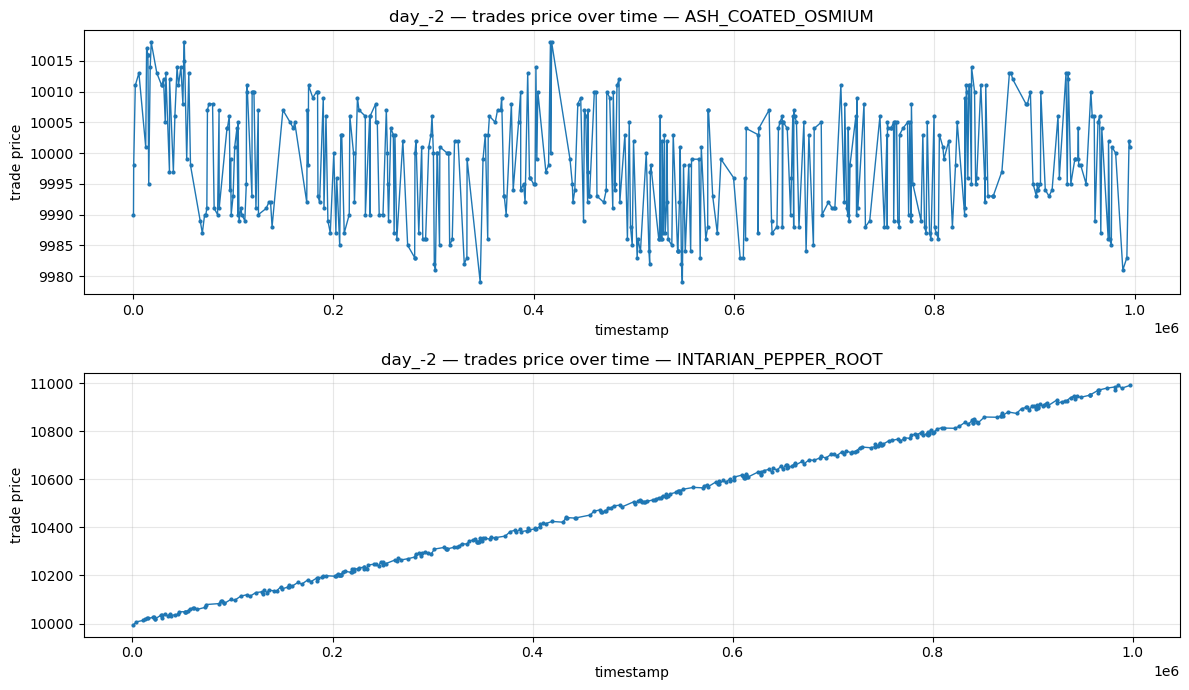

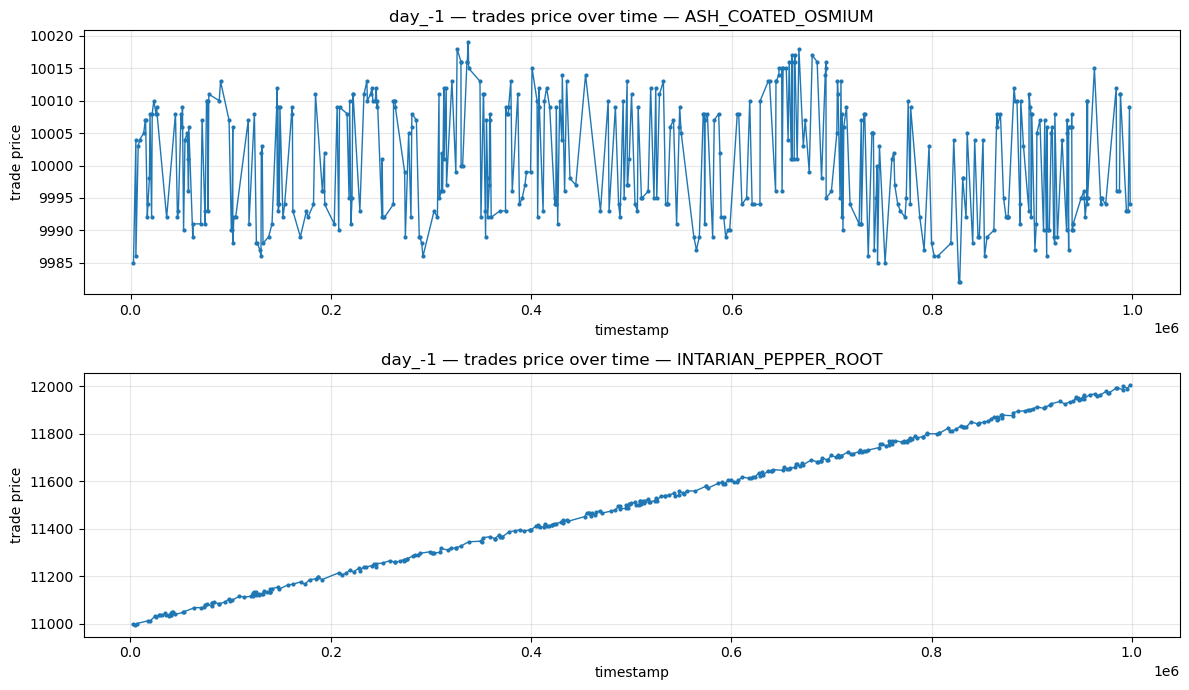

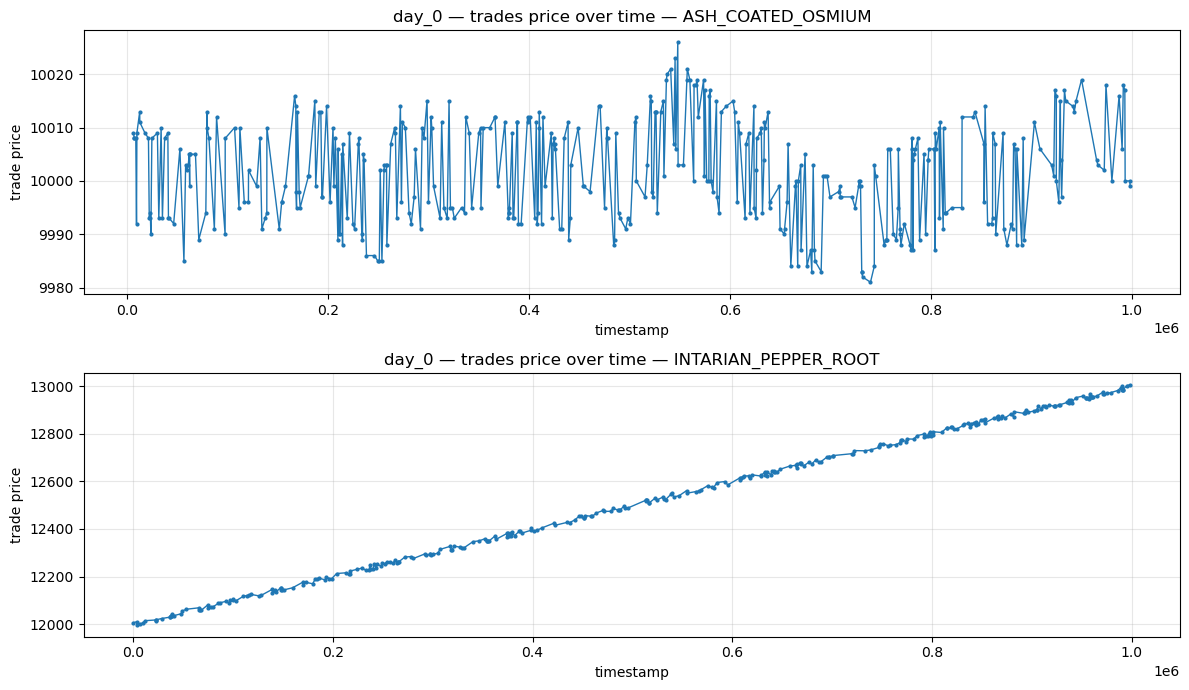

In [5]:
for day_name, df in trade_days.items():
    symbols = sorted(df["symbol"].dropna().unique())
    fig, axes = plt.subplots(len(symbols), 1, figsize=(12, 3.5 * len(symbols)))
    if len(symbols) == 1:
        axes = [axes]

    for ax, sym in zip(axes, symbols):
        g = df[df["symbol"] == sym].sort_values("timestamp")
        ax.plot(g["timestamp"], g["price"], marker="o", ms=2, lw=1)
        ax.set_title(f"{day_name} — trades price over time — {sym}")
        ax.set_xlabel("timestamp")
        ax.set_ylabel("trade price")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

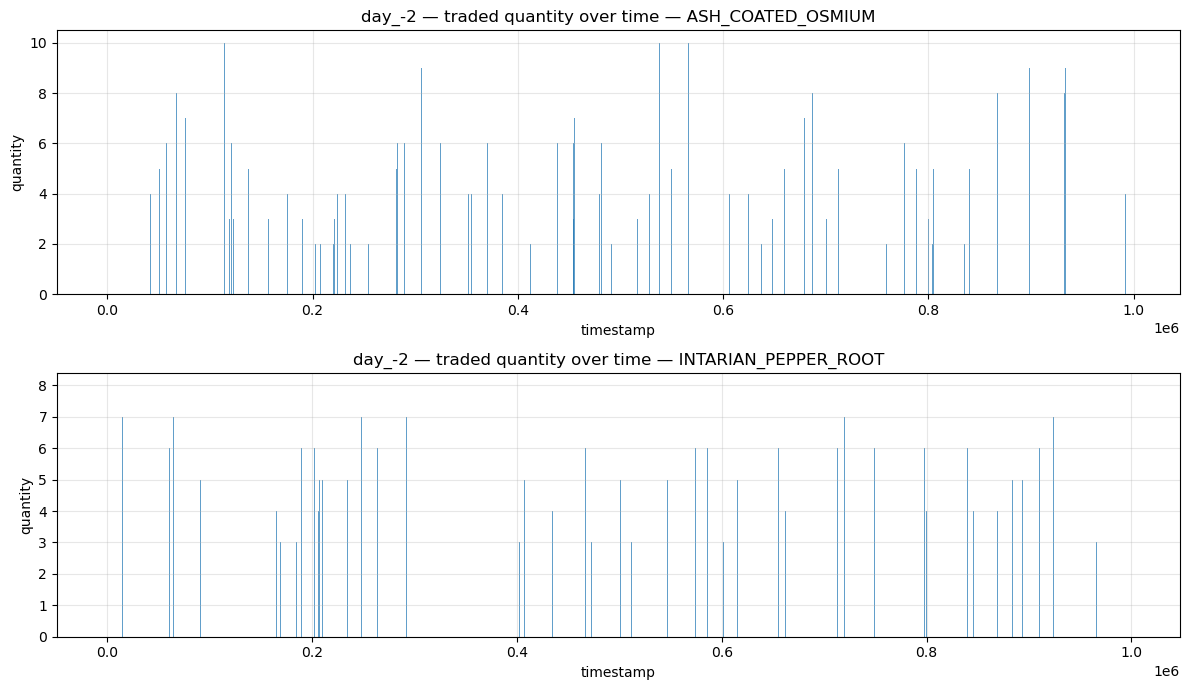

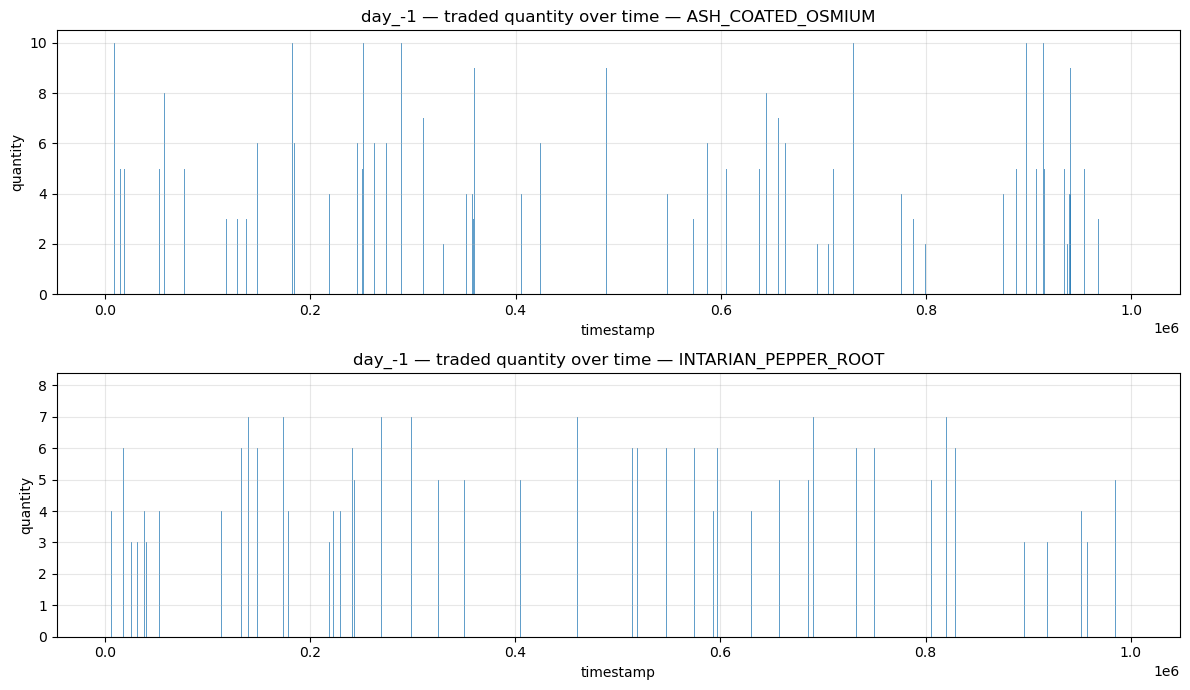

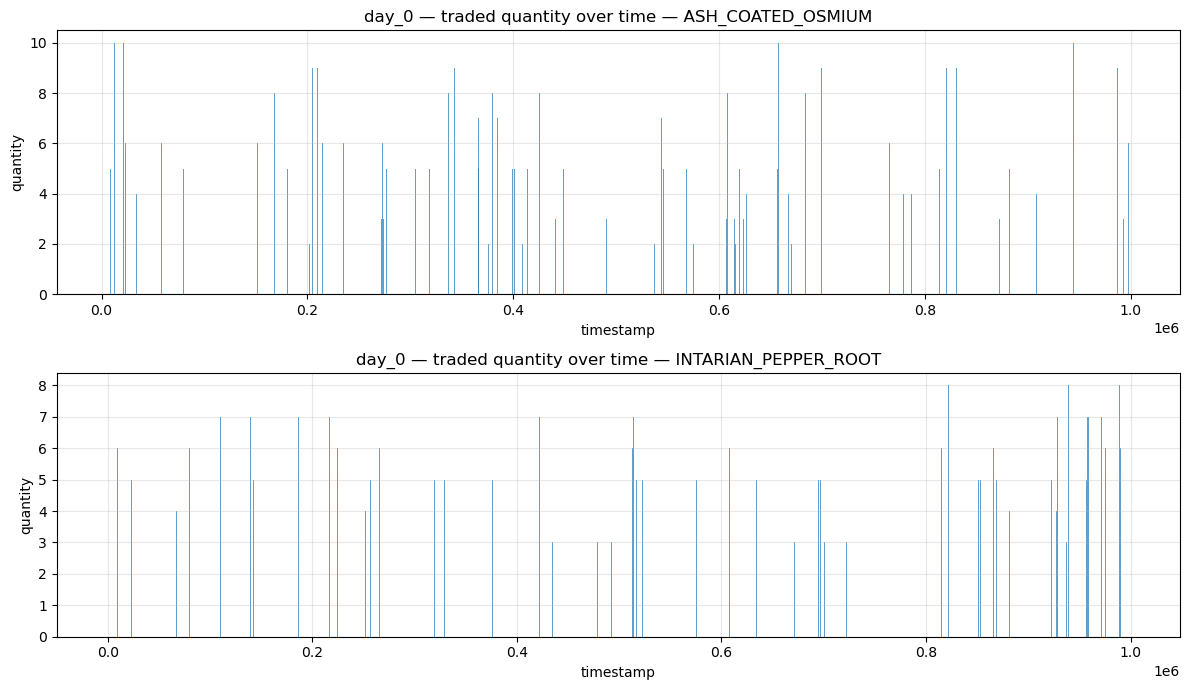

In [6]:
for day_name, df in trade_days.items():
    symbols = sorted(df["symbol"].dropna().unique())
    fig, axes = plt.subplots(len(symbols), 1, figsize=(12, 3.5 * len(symbols)))
    if len(symbols) == 1:
        axes = [axes]

    for ax, sym in zip(axes, symbols):
        g = df[df["symbol"] == sym].sort_values("timestamp")
        ax.bar(g["timestamp"], g["quantity"], width=150, alpha=0.7)
        ax.set_title(f"{day_name} — traded quantity over time — {sym}")
        ax.set_xlabel("timestamp")
        ax.set_ylabel("quantity")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

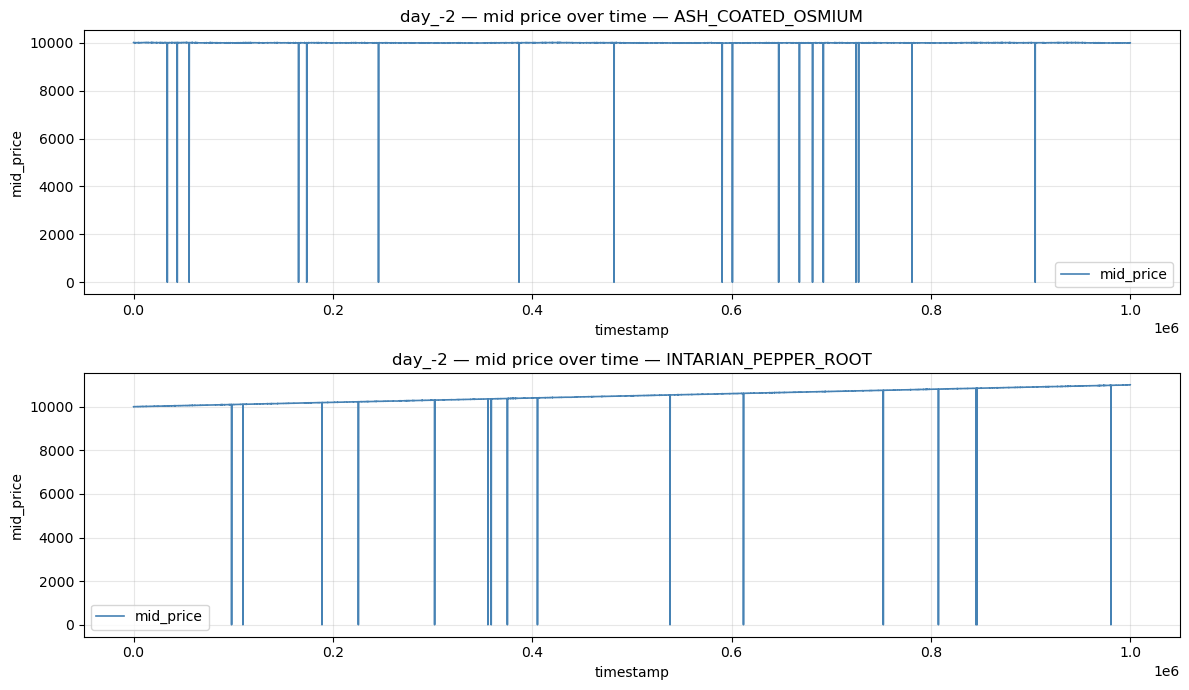

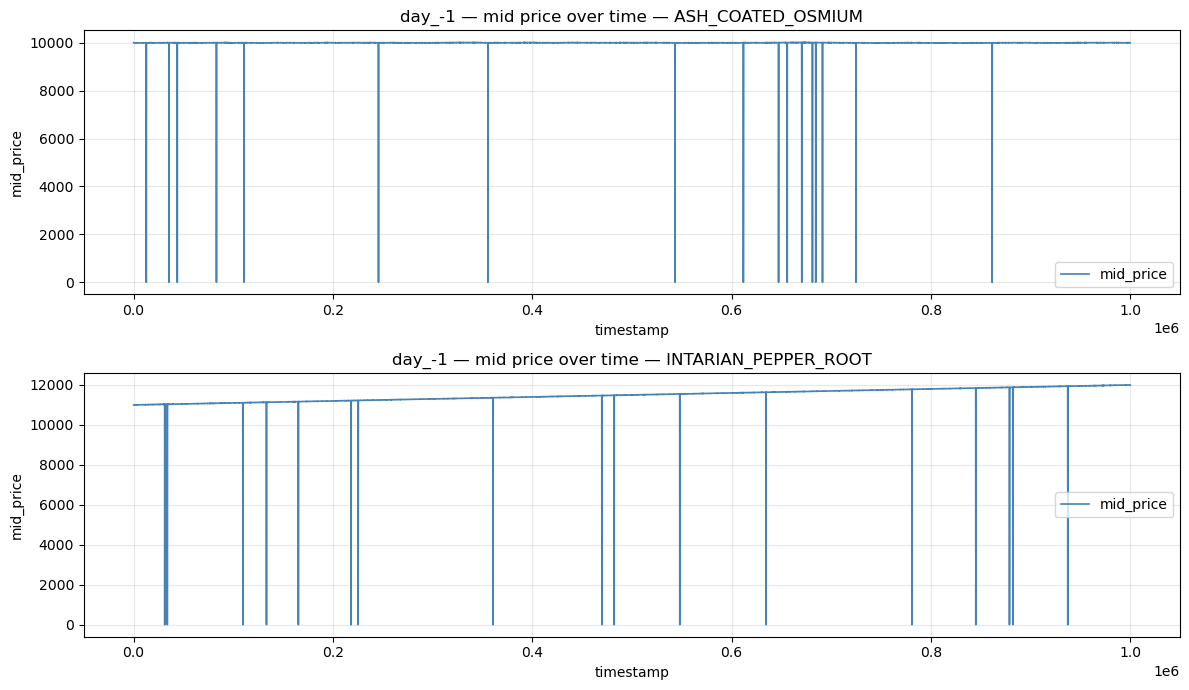

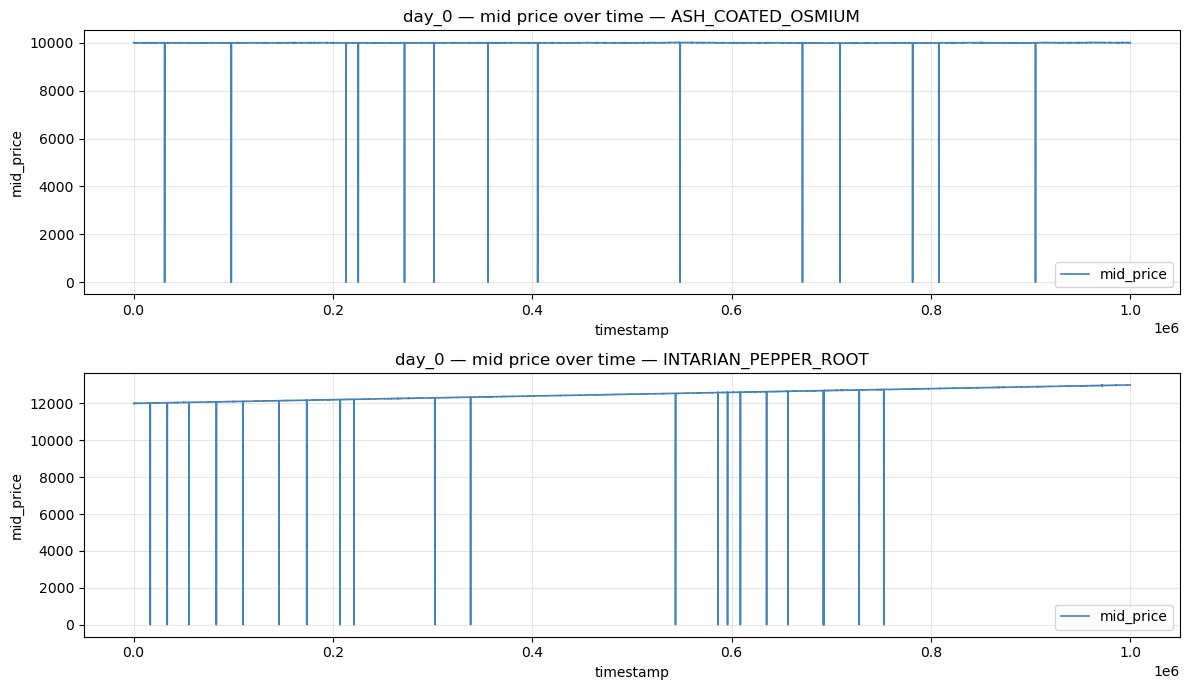

In [7]:
for day_name, df in price_days.items():
    products = sorted(df["product"].dropna().unique())
    fig, axes = plt.subplots(len(products), 1, figsize=(12, 3.5 * len(products)))
    if len(products) == 1:
        axes = [axes]

    for ax, product in zip(axes, products):
        g = df[df["product"] == product].sort_values("timestamp")
        ax.plot(g["timestamp"], g["mid_price"], lw=1.2, color="steelblue", label="mid_price")
        ax.set_title(f"{day_name} — mid price over time — {product}")
        ax.set_xlabel("timestamp")
        ax.set_ylabel("mid_price")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()